In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/home/b/b384080/.conda/envs/eekenv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
def first_zero_crossing(da):
    """
    Return the first time where the data crosses zero, ignoring NaNs.
    """
    valid = da.notnull()
    da = da.where(valid, drop=True)

    values = da.values

    idx = np.where(np.diff(np.sign(values)) != 0)[0]

    if len(idx) == 0:
        return None

    return da.time[idx[0] + 1]

def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2','mol/m2/s x m2']:
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kg/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['gC/m^2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cSoil' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cVeg' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'dissic' and stat == 'integral' and vert_stat == 'integral' and da.units in ['mol m-3 x m x m2']:
        converter = 12.0107 /1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
        
    elif varia == 'co2mass' and stat is None and vert_stat is None and da.units in ['kg']:
        converter = 12.0107 / 44.011 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'co2mass' and stat == 'integral' and vert_stat is None and da.units in ['kg CO2/m2 x m2']:   # this case corresponds to NASA-GISS
        converter = 12.0107 / 44.011 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
        
    elif varia == 'fco2antt' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s','kg s-1 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and vert_stat is None and da.units in ['gC/m^2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'fgco2' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'fgco2' and stat == 'integral' and vert_stat is None and da.units in ['mmol/m^3 cm/s x m2 x s']:
        converter = 10**-5 * 12.0107/ 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    else:
        da_conv = da

    return da_conv

def get_stat(varia,model):

    # default settings
    if varia in ['tas','tos']:
        stat = 'mean'
    elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter','dissic','fco2antt']:
        stat = 'integral'
    elif varia in ['co2mass']:
        stat = None

    # overwrite some choices
    if model == 'GISSE2.1-G-CC2':
        if varia == 'co2mass':
            stat = 'integral'
    
    return stat


def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat
    
def get_infix(varia,default=True):
    infix_base = 'vertical_'
    if default == True:
        if varia in ['dissic']:
            infix = infix_base+'integral_'
        else:
            infix = ''
    else:
        infix = ''
    return infix    

def get_suffix(varia,default=True):
    if default == True:
        if varia in ['fco2antt','fgco2','nbp']:
            suffix = '_cumulated'
        else:
            suffix = ''
    else:
        suffix = ''
    return suffix    

In [3]:
varias = ['tas','fgco2','nbp','co2mass','fco2antt']#,'dissic','cLand'] # ,'cLand','dissic'.  # 'tas','tos',
models = ['ACCESS-ESM1-5','MIROC-ES2L','GFDL-ESM2M','IPSL-CM6-ESMCO2','NorESM2-LM','GISSE2.1-G-CC2','EC-Earth3-ESM-1','CESM2','UKESM1-2']#]#,'IPSL-CM6-ESMCO2']#,'GFDL-ESM2M','NorESM2-LM','UKESM1-2','EC-Earth3-ESM-1']#['GISSE2.1-G-CC2'].   #]#, ]#, # 
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1
root_dir = f'./../01_postprocessed_data/global_time_series'

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'monthly'#'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

In [4]:
def get_reference_value(varia,model):
    freq_input = get_freq_input(model)
    stat = get_stat(varia,model)
    vert_stat = get_vert_stat(varia,default=True)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    infix = get_infix(varia,default=True)
    suffix = get_suffix(varia,default=True)
    run = 'esm-piControl'
    load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
    load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'

    global_stat = xr.open_dataset(load_string,use_cftime=True)
    global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
    global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    
    if varia == 'tas':
        annual_stat = global_stat.resample(time="1YS").mean()
    else:
        annual_stat = global_stat.resample(time="1YS").first()

    if model == 'ACCESS-ESM1-5':
        reference_value = annual_stat.sel(time=f'{ref_year+170:04d}-01-01').values
    else:
        try:
            reference_value = annual_stat.sel(time=f'{ref_year:04d}-01-01').values
        except:
            reference_value = annual_stat.sel(time=f'{ref_year+1:04d}-01-01').values



    return reference_value


running_mean_years = 11

all_annual_stats = dict()
for varia in varias:
    all_annual_stats[varia] = dict()
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia,model)
        vert_stat = get_vert_stat(varia,default=True)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        infix = get_infix(varia,default=True)
        suffix = get_suffix(varia,default=True)
        #print(varia,model)
        #print(varia,model,reference_value)
        #color = model_dict[model].color_id
        annual_stats = dict()
        for run in runs:
            try:
                reference_value = get_reference_value(varia,model)
                #print(reference_value)
                color = model_dict[model].color_id#run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
                global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
                #print(global_stat.values)
                #print(global_stat.time)
    
                if varia == 'tas':
                    annual_stat = global_stat.resample(time="1YS").mean()
                else:
                    annual_stat = global_stat.resample(time="1YS").last()
    
                #if varia == 'co2mass':
                #    offsetter = get_offset_value(varia,model,reference_value)
                #    annual_stat = annual_stat + offsetter
    
                # correct for reference value
                annual_stat = annual_stat - reference_value
                
                annual_stat.attrs['units'] = global_stat.units
                
                # convert
                annual_stat = convert_units(varia,stat,annual_stat)
    
                # get the start and end
                time_slice = TimeOperator.get_time_start_and_end(model,run,model_dict,ref_year=ref_year)
                annual_stat = annual_stat.sel(time=time_slice)
                
                
                # if model == 'GISS' and variable is fco2antt, divide multiply with 12.0107 / 44.011 (is erroneously reported as kgCO2/m2/s instead of kgC/m2/s)
                if model == 'GISSE2.1-G-CC2':
                    if varia == 'fco2antt':
                        annual_stat = annual_stat * 12/44 # 12.0107/44.011

                #if varia == 'tas':
                #    annual_stat = annual_stat.rolling(time=running_mean_years,center=True,min_periods=1).mean()
                
                # put into dictionary
                annual_stats[run] = annual_stat

            except:
                print(f'Nothing to do for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
        all_annual_stats[varia][model] = annual_stats    

/tmp/ipykernel_447643/2551768151.py:13: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_447643/2551768151.py:59: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)


None


/tmp/ipykernel_447643/2551768151.py:13: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_447643/2551768151.py:59: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_447643/2551768151.py:13: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

0198-12-31 00:00:00


/tmp/ipykernel_447643/2551768151.py:59: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)


...

None


/tmp/ipykernel_447643/2551768151.py:13: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_447643/2551768151.py:59: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)


None


/tmp/ipykernel_447643/2551768151.py:13: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_447643/2551768151.py:59: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)


None


## Now get the vertical profiles

In [22]:
#root_root = '/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle'
root_root = '/home/b/b384080/TIPMIP_carbon_cycle'#/01_postprocessed_data/vertical_profiles'
outroot = f'{root_root}/01_postprocessed_data/vertical_profiles'

#member = '001'
freq_input = 'monthly'
stat = 'mean'
model = 'CESM2' #'GISSE2.1-G-CC2' # 'EC-Earth3-ESM-1' #'GFDL-ESM2M'#'IPSL-CM6-ESMCO2'#'NorESM2-LM'#'CESM2'#'NorESM2-LM'#'IPSL-CM6-ESMCO2'#'GFDL-ESM2M'#'CESM2'#'IPSL-CM6-ESMCO2'#'GFDL-ESM2M'#
varia = 'thetao'#'o2'#'dissic'#'dissic'#'thetao'##'o2'
ref_year = 1

if model == 'CESM2':
    member = '001'
elif model == 'NorESM2-LM':
    member = 'r1i1p1f1'
elif model == 'IPSL-CM6-ESMCO2':
    member = 'r1i2p3f1'
elif model == 'GFDL-ESM2M':
    member = 'r1i1p1f1'
elif model == 'GISSE2.1-G-CC2':
    member = 'r1i1p1f3'
elif model == 'EC-Earth3-ESM-1':
    member = 'r1i1p1f1'

if varia == 'thetao':
    unit = "°C"
    vmin = -4
    vmax = 4
    cmap = 'cmo.balance'
elif varia == 'dissic':
    unit = r'mmol m$^{-3}$'
    vmin = -260
    vmax = 260
    cmap = 'cmo.balance_r'
elif varia == 'o2':
    unit = r'mmol m$^{-3}$'
    vmin = -40
    vmax = 40
    cmap = 'BrBG'
elif varia == 'so':
    unit = r'- or g/kg'
    vmin = -1
    vmax = 1
    cmap = 'cmo.curl'
elif varia == 'no3':
    unit = r'mmol m-3'
    vmin = -3
    vmax = 3
    cmap = 'cmo.curl_r'

runs = ['esm-piControl','esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0']

dd = dict()
for rdx,run in enumerate(runs):
    save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
    save_string = f'{varia}_{model}_{run}_{member}_global_{stat}.nc'
    dd[run] = xr.open_dataset(f'{save_dir}/{save_string}',use_cftime=True) #* 1000. #.groupby('time.year').mean('time')
    if varia == 'dissic' and dd[run][f'{varia}_global_mean'].attrs['units'] == 'mol m-3': # see NorESM2-LM
        dd[run] = dd[run]*1000.
    if varia == 'o2' and dd[run][f'{varia}_global_mean'].attrs['units'] == 'mol m-3': # see NorESM2-LM
        dd[run] = dd[run]*1000.
    if varia == 'no3' and dd[run][f'{varia}_global_mean'].attrs['units'] == 'mol m-3': # see NorESM2-LM
        dd[run] = dd[run]*1000.
    dd[run] = TimeOperator.shift_time_axis_to_ref_year(model, dd[run],ref_year=ref_year,set_to_start_of_months=True)


troot = f'{root_root}/01_postprocessed_data/global_time_series'
taria = 'tas'
dt = dict()
for rdx,run in enumerate(runs):
    tave_dir = f'{troot}/{taria}/{model}/{run}/{member}/{freq_input}/global_{stat}'
    tave_string = f'{taria}_{model}_{run}_{member}_global_{stat}.nc'
    dt[run] = xr.open_dataset(f'{tave_dir}/{tave_string}',use_cftime=True)#.groupby('time.year').mean('time')
    dt[run] = TimeOperator.shift_time_axis_to_ref_year(model, dt[run],ref_year=ref_year,set_to_start_of_months=True)


/tmp/ipykernel_447643/3146873777.py:57: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  dd[run] = xr.open_dataset(f'{save_dir}/{save_string}',use_cftime=True) #* 1000. #.groupby('time.year').mean('time')
/tmp/ipykernel_447643/3146873777.py:57: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  dd[run] = xr.open_dataset(f'{save_dir}/{save_string}',use_cftime=True) #* 1000. #.groupby('time.year').mean('time')
/tmp/ipykernel_447643/3146873777.py:57: FutureWarning: Usage of 'use_cftime' as a kwarg is

esm-up2p0-gwl2p0
<xarray.DataArray 'time' ()> Size: 8B
array(cftime.DatetimeProlepticGregorian(281, 1, 1, 0, 0, 0, 0, has_year_zero=True),
      dtype=object)
Coordinates:
    time     object 8B 0281-01-01 00:00:00


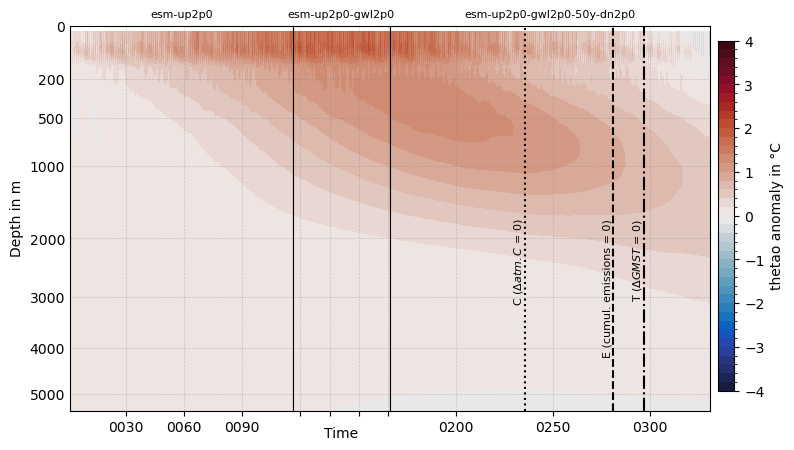

esm-up2p0-gwl4p0
<xarray.DataArray 'time' ()> Size: 8B
array(cftime.DatetimeProlepticGregorian(511, 1, 1, 0, 0, 0, 0, has_year_zero=True),
      dtype=object)
Coordinates:
    time     object 8B 0511-01-01 00:00:00


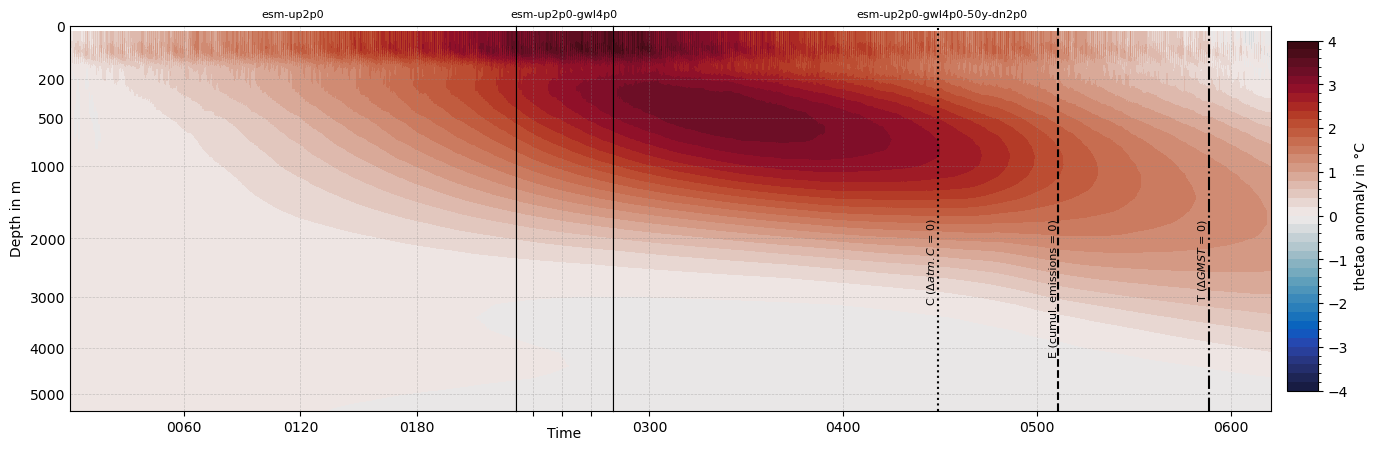

In [23]:
# ----------------------------------------------------------
# branches
# ----------------------------------------------------------

cycles = {
    "2K": "esm-up2p0-gwl2p0",
    "4K": "esm-up2p0-gwl4p0",
}

#vmin, vmax = -4,4 #-160, 160 , #-40, 40

# ----------------------------------------------------------
# reference
# ----------------------------------------------------------

ref_profile = (
    dd["esm-up2p0"][f"{varia}_global_{stat}"]
    .isel(time=slice(0, 12))
    .mean("time")
)

# ----------------------------------------------------------
# helpers
# ----------------------------------------------------------

def cut_50y(da, run):
    if "50y-dn2p0" in run:
        return da.isel(time=slice(0, 50 * 12))
    return da

def nyears(da):
    return da.sizes["time"] / 12

def t0(da):
    return da.time.values[0]

# ----------------------------------------------------------
# plot
# ----------------------------------------------------------

def plot(ax, da, cmap):

    if "z_t" in da.dims:
        da = (da - ref_profile).transpose("z_t", "time")
        z = da["z_t"].values

    elif "lev" in da.dims:
        da = (da - ref_profile).transpose("lev", "time")
        z = da["lev"].values      

    elif "olevel" in da.dims:
        da = (da - ref_profile).transpose("olevel", "time")
        z = da["olevel"].values              
        
    # ------------------------------------------------------
    # NONLINEAR DEPTH TRANSFORM
    # ------------------------------------------------------

    zmax = np.nanmax(z)
    alpha = 0.6

    z_trans = (z / zmax) ** alpha

    if "z_t" in da.dims:
        da = da.assign_coords(z_t=z_trans)
        depth_dim = 'z_t'
    elif "lev" in da.dims:
        da = da.assign_coords(lev=z_trans)
        depth_dim = 'lev'
    elif "olevel" in da.dims:
        da = da.assign_coords(olevel=z_trans)
        depth_dim = 'olevel'  

    im = da.plot.contourf(
        ax=ax,
        x="time",
        y=depth_dim,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=41,
        add_colorbar=False,
    )

    # ------------------------------------------------------
    # ROUND PHYSICAL DEPTH TICKS (IMPORTANT PART)
    # ------------------------------------------------------

    tick_phys = np.array([
        0, 200, 500, 1000,
        2000, 3000, 4000, 5000
    ])
    
    if np.max(z)>10000:
        tick_phys = tick_phys * 100.

    # keep only valid ones
    tick_phys = tick_phys[tick_phys <= zmax]

    # transform them using SAME mapping
    tick_trans = (tick_phys / zmax) ** alpha

    ax.set_yticks(tick_trans)

    if np.max(z)>10000:
        ax.set_yticklabels([str(int(t/100.)) for t in tick_phys])
    else:
        ax.set_yticklabels([str(int(t)) for t in tick_phys])

    ax.invert_yaxis()

    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis="y", length=0)
    ax.margins(x=0)

    return im

# ----------------------------------------------------------
# LOOP OVER CASES
# ----------------------------------------------------------

for cycle, gwl_run in cycles.items():

    print(gwl_run)
    # ------------------------------------------------------
    # datasets
    # ------------------------------------------------------

    esm = dd["esm-up2p0"][f"{varia}_global_{stat}"]
    gwl = dd[gwl_run][f"{varia}_global_{stat}"]
    rec = dd[f"{gwl_run}-50y-dn2p0"][f"{varia}_global_{stat}"]

    rec = cut_50y(rec, "x")

    # ------------------------------------------------------
    # causal truncation
    # ------------------------------------------------------

    t_mid = t0(gwl)
    t_right = t0(rec)

    esm_cut = esm.sel(time=slice(None, t_mid))
    gwl_cut = gwl.sel(time=slice(None, t_right))
    rec_cut = rec

    datasets = [esm_cut, gwl_cut, rec_cut]

    # ------------------------------------------------------
    # widths (years per panel)
    # ------------------------------------------------------

    widths = [nyears(d) for d in datasets]
    total_years = sum(widths)

    # ------------------------------------------------------
    # FIGURE SIZE SCALES WITH TOTAL YEARS
    # ------------------------------------------------------

    fig_width = max(1, total_years/40)
    fig_height = 5

    fig = plt.figure(figsize=(fig_width, fig_height))

    gs = fig.add_gridspec(
        1, 3,
        width_ratios=widths,
        wspace=0.0,   # no gaps
        right=0.9
    )

    axes = []
    ims = []

    labels = [
        "esm-up2p0",
        gwl_run,
        f"{gwl_run}-50y-dn2p0",
    ]

    # ------------------------------------------------------
    # plotting
    # ------------------------------------------------------

    for i, da in enumerate(datasets):
        ax = fig.add_subplot(gs[0, i])

        ims.append(plot(ax, da, cmap))

        ax.set_title(labels[i],fontsize=8)

        #print(da.time.values[0])
        #print(da.time.values[-1])

        ax.set_xlim(da.time.values[0], da.time.values[-1])

        axes.append(ax)

    axes[0].set_ylabel("Depth in m")

    for adx,axi in enumerate(axes):
        if adx != 0:
            axi.set_yticklabels([])
        axi.grid(alpha=0.4,linewidth=0.5,linestyle='--',color='#888888')
        
    for adx,axi in enumerate(axes):
        if adx == 1:
            axi.set_xticklabels([])
            axi.set_xlabel("Time")


    # ------------------------------------------------
    # marker at net-zero year
    # ------------------------------------------------
    # ------------------------------------------------
    # zero-crossing time from cumulative emissions
    # ------------------------------------------------

    emissions = all_annual_stats["fco2antt"][model][f'{gwl_run}-50y-dn2p0']
    zero_time_emissions = first_zero_crossing(emissions)
    print(zero_time_emissions)
    
    co2_mass = all_annual_stats["co2mass"][model][f'{gwl_run}-50y-dn2p0']
    zero_time_co2mass = first_zero_crossing(co2_mass)    

    annual_temp_rm31 = all_annual_stats["tas"][model][f'{gwl_run}-50y-dn2p0'].rolling(time=running_mean_years,center=True,min_periods=1).mean() #.rolling(time=31, center=True).mean()
    zero_time_temp = first_zero_crossing(annual_temp_rm31)   


    if zero_time_emissions is not None:
        ax.axvline(
            zero_time_emissions.item(),
            color="k",
            linestyle="--",
            zorder=10,
        )
        ax.text(
            zero_time_emissions.item(),
            (ax.get_ylim()[0]-ax.get_ylim()[1])/2,
            "E (cumul. emissions = 0)",
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            backgroundcolor="none",
        )
    if zero_time_co2mass is not None:
        ax.axvline(
            zero_time_co2mass.item(),
            color="k",
            linestyle=":",
            zorder=10,
        )
        ax.text(
            zero_time_co2mass.item(),
            (ax.get_ylim()[0]-ax.get_ylim()[1])/2,
            "C ($\Delta atm. C$ = 0)",
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            backgroundcolor="none",
        )
    
    if zero_time_temp is not None:
        ax.axvline(
            zero_time_temp.item(),
            color="k",
            linestyle="-.",
            zorder=10,
        )
        ax.text(
            zero_time_temp.item(),
            (ax.get_ylim()[0]-ax.get_ylim()[1])/2,
            "T ($\Delta GMST$ = 0)",
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            backgroundcolor="none",
        )    
    # ------------------------------------------------------
    # colorbar
    # ------------------------------------------------------

    cax = fig.add_axes([0.91,0.15,0.02,0.7])
    fig.colorbar(
        ims[0],
        cax=cax,
        fraction=0.03,
        pad=0.02,
        label=f"{varia} anomaly in {unit}"
    )

    plot_dir = f'./../03_plots/vertical_profile_global_statistic/{varia}/{model}/global_{stat}/ref_first_year_of_rampup'
    os.makedirs(plot_dir,exist_ok = True)
    plot_filename = f'vertical_profile_{varia}_{model}_global_{stat}_ref_first_year_of_rampup_{cycle}cycle.png'
    fig.savefig(f'{plot_dir}/{plot_filename}',dpi=150,transparent=True)
    plt.show()

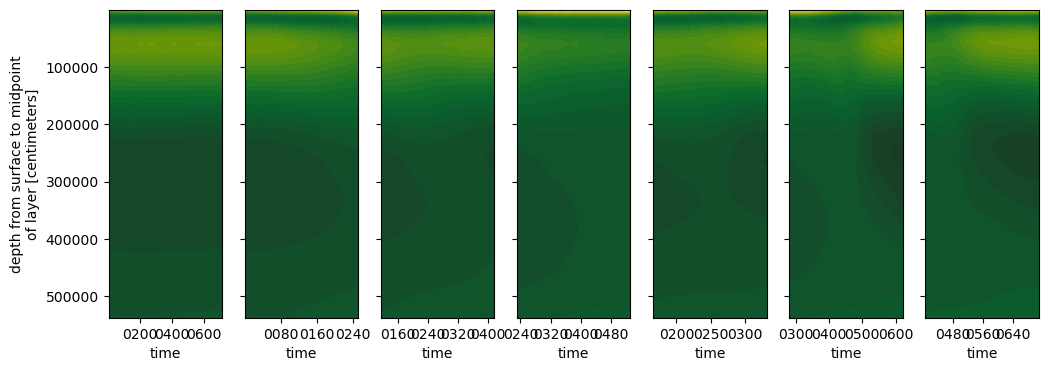

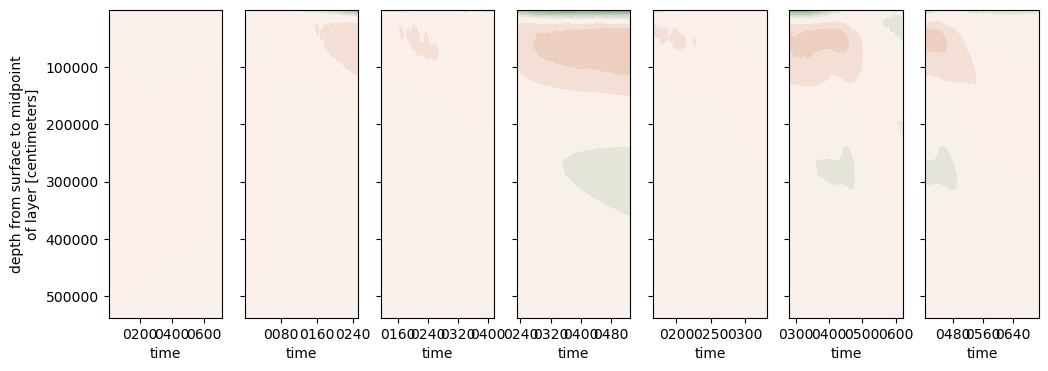

In [12]:
ref_profile = dd['esm-up2p0'][f'{varia}_global_{stat}'].isel(time=slice(0,12)).mean("time")

fig, ax = plt.subplots(1, 7, figsize=(12, 4),sharey=True)

for kdx,key in enumerate(dd.keys()):
    da = (dd[key][f'{varia}_global_{stat}']).T

    da.plot.contourf(
        ax=ax[kdx],
        x="time",
        y="z_t", # "lev",#"z_t","lev",# 
        cmap="cmo.speed",#"cmo.haline",#,"BrBG",#
        vmin=34,
        vmax=35, #0.1,
        levels=41,
        add_colorbar=False,   # don't make one automatically
    )
for adx,a in enumerate(ax):
    a.invert_yaxis()
    if adx != 0:
        a.set_ylabel('')

plt.show()


fig, ax = plt.subplots(1, 7, figsize=(12, 4),sharey=True)

for kdx,key in enumerate(dd.keys()):
    da = (dd[key][f'{varia}_global_{stat}'] - ref_profile).T

    da.plot.contourf(
        ax=ax[kdx],
        x="time",
        y="z_t", # "lev",#,"lev",# 
        cmap="cmo.curl",#,"BrBG",#
        vmin=-1,#-.002,
        vmax=1,#.002,
        levels=41,
        add_colorbar=False,   # don't make one automatically
    )
for adx,a in enumerate(ax):
    a.invert_yaxis()
    if adx != 0:
        a.set_ylabel('')

plt.show()

/tmp/ipykernel_493594/805303689.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


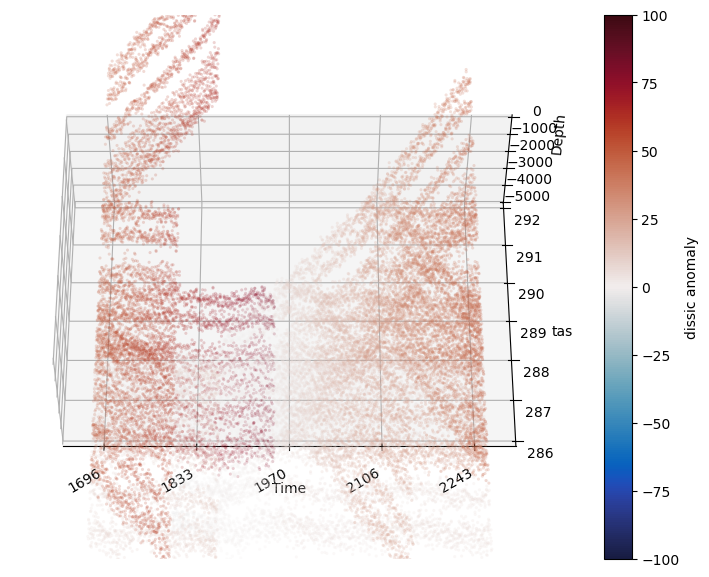

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from matplotlib.colors import Normalize
import cmocean as cmo

# ----------------------------------------------------------
# reference
# ----------------------------------------------------------

ref_profile = (
    dd["esm-up2p0"][f"{varia}_global_{stat}"]
    .isel(time=0)
)

#z_new = np.arange(
#    0,
#    dd["esm-up2p0"].z_t.max().values,
#    10
#)

# ----------------------------------------------------------
# figure
# ----------------------------------------------------------

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

norm = Normalize(vmin=-100, vmax=100)
cmap = 'cmo.balance'

# convert time → matplotlib numeric dates
# (works for datetime64 and cftime converted via pandas)
def to_mpl_time(t):
    return mdates.date2num(np.array(t, dtype="datetime64[ns]"))

# ----------------------------------------------------------
# loop
# ----------------------------------------------------------

for kdx,key in enumerate(dd.keys()):

    da = (
        dd[key][f"{varia}_global_{stat}"]
        - ref_profile
    ).transpose("lev", "time") #"z_t"

    # --------------------------------------------------
    # interpolate to 10 m grid
    # --------------------------------------------------
    da = da.interp(lev=np.arange(0, da.lev.max(), 5000))

    # Only keep first 50 times (600 monthly values)
    #if key in ["esm-up2p0-gwl2p0","esm-up2p0-gwl4p0"]:
    #    da = da.isel(time=slice(0, 50))
    #    dt[key] = dt[key].isel(time=slice(0, 50))
    
    
    time = to_mpl_time(da.time.values)
    depth = da.lev.values.astype(float)

    ts = dt[key][f"{taria}_global_{stat}"].sel(time=da.time)

    # same real time axis
    temp = ts.values.astype(float)

    # expand grid
    T, Z = np.meshgrid(time, depth)
    Y = np.tile(temp, (len(depth), 1))

    # scatter representation of curtain
    ax.scatter(
        T.ravel(),
        Y.ravel(),
        -Z.ravel(),
        c=da.values.ravel(),
        cmap=cmap,
        norm=norm,
        s=5,
        alpha=0.2,
        linewidths=0,
        zorder=kdx,
    )

# ----------------------------------------------------------
# formatting
# ----------------------------------------------------------

ax.set_xlabel("Time")
ax.set_ylabel(f"{taria}")
ax.set_ylim([286,292])
ax.set_zlabel("Depth")
ax.set_zlim([-500000,0])


ax.set_zlim(-depth.max(), 0)

# format time axis properly
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

# colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.colorbar(sm, ax=ax, label=f"{varia} anomaly")


ax.set_box_aspect((3, 2, 1))
ax.view_init(elev=55, azim=270)

plt.tight_layout()
plt.show()